XGBoost: gradient boosting, where each tree corrects the *errors* of the previous trees (unlike Random Forest, where trees are independent and just vote). Requires `pip install xgboost` (already installed in this environment).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("xgboost version:", xgb.__version__)

Train: (398, 30), Test: (171, 30)
xgboost version: 3.3.0


In [2]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42,
)
xgb_clf.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False,
)

y_pred = xgb_clf.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Test accuracy: 95.91%
              precision    recall  f1-score   support

   malignant       0.97      0.92      0.94        64
      benign       0.95      0.98      0.97       107

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



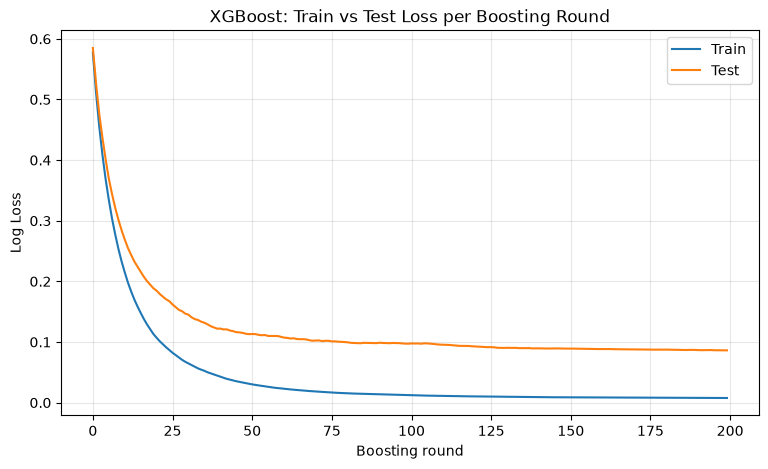

In [3]:
# Training curve: watch train vs test logloss across boosting rounds
results = xgb_clf.evals_result()
epochs = range(len(results['validation_0']['logloss']))

plt.figure(figsize=(9, 5))
plt.plot(epochs, results['validation_0']['logloss'], label='Train')
plt.plot(epochs, results['validation_1']['logloss'], label='Test')
plt.xlabel('Boosting round')
plt.ylabel('Log Loss')
plt.title('XGBoost: Train vs Test Loss per Boosting Round')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
# Early stopping: stop adding trees once test loss stops improving (prevents overfitting)
xgb_early = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.1,
    eval_metric='logloss',
    early_stopping_rounds=10,
    random_state=42,
)
xgb_early.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

print(f"Best iteration: {xgb_early.best_iteration} (out of 500 requested)")
print(f"Test accuracy with early stopping: {accuracy_score(y_test, xgb_early.predict(X_test))*100:.2f}%")

Best iteration: 84 (out of 500 requested)
Test accuracy with early stopping: 95.32%


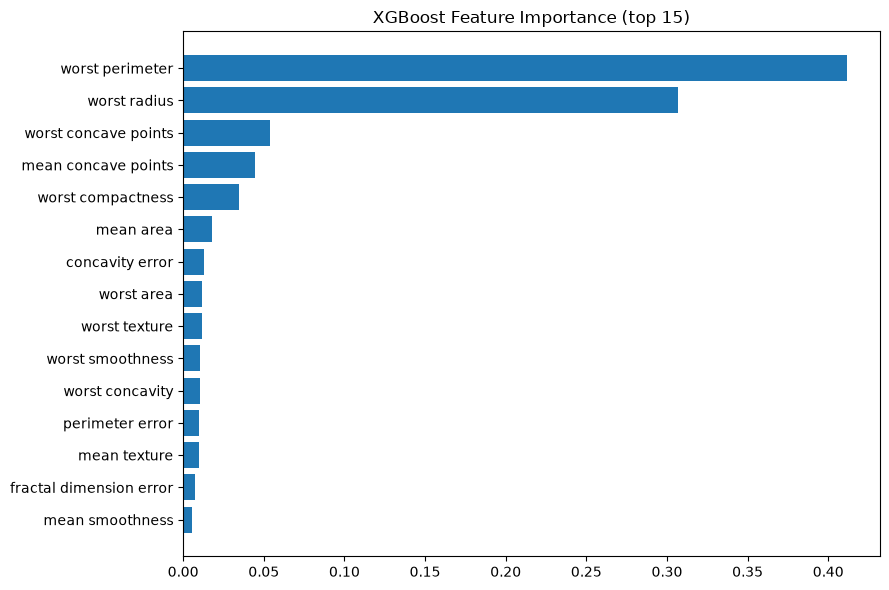

In [5]:
# Feature importance
importances = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_clf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(9, 6))
plt.barh(importances['feature'], importances['importance'])
plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importance (top 15)')
plt.tight_layout()
plt.show()

In [6]:
# Compare against Random Forest (bagging) to see boosting's edge
rf = RandomForestClassifier(n_estimators=200, max_depth=3, random_state=42)
rf.fit(X_train, y_train)

print(f"Random Forest test accuracy: {accuracy_score(y_test, rf.predict(X_test))*100:.2f}%")
print(f"XGBoost test accuracy:       {accuracy_score(y_test, xgb_clf.predict(X_test))*100:.2f}%")
print("\nBoosting builds trees sequentially, each one targeting the previous ensemble's residual error.")
print("Bagging (Random Forest) builds trees independently and averages/votes -- no error-correction loop.")

Random Forest test accuracy: 93.57%
XGBoost test accuracy:       95.91%

Boosting builds trees sequentially, each one targeting the previous ensemble's residual error.
Bagging (Random Forest) builds trees independently and averages/votes -- no error-correction loop.
